In [1]:
# @title Import Library
!pip install gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

In [2]:
# @title Dataset Source
# https://www.kaggle.com/datasets/indraputra21/used-car-listings-in-indonesia?select=used_car.csv
# https://drive.google.com/file/d/1GYiD5S-N5qQOzoI1bUatEIZwtWxl2u0i/view?usp=sharing
FILE_ID = "1GYiD5S-N5qQOzoI1bUatEIZwtWxl2u0i"
FILE_NAME = "car_used.csv"

!gdown {FILE_ID} -O {FILE_NAME}

Downloading...
From: https://drive.google.com/uc?id=1GYiD5S-N5qQOzoI1bUatEIZwtWxl2u0i
To: /content/car_used.csv
100% 65.8k/65.8k [00:00<00:00, 20.5MB/s]


In [3]:
# @title Load Dataset
df = pd.read_csv(FILE_NAME)
df.head()

,car name,brand,year,mileage (km),location,transmission,plate type,rear camera,sun roof,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp),instalment (Rp|Monthly)
0,AYLA X 1.2,Daihatsu,2018,10.508,Jakarta Utara,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,101000000,2060000
1,AGYA TRD SPORTIVO 1.0,Toyota,2015,112.888,Bogor,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,82000000,1670000
2,X-TRAIL 2.5,Nissan,2015,118.429,Surabaya,Automatic,odd plate,0,0,0,0,0,0,1,0,1,0,0,169000000,3440000
3,YARIS S TRD 1.5,Toyota,2020,15.945,Tangerang Selatan,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,218000000,4440000
4,AGYA G 1.2,Toyota,2019,30.404,Jakarta Barat,Manual,odd plate,0,0,0,0,0,0,0,0,0,0,0,117000000,2380000


In [4]:
# @title EDA
# Memahami struktur dataset
# Cek Ukuran dataset
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

# Informasi dataset
print("\n")
df.info()

# Nama kolom
print("\n")
df.columns.tolist()

# Statistik deskriptif
print("\n")
df.describe()

Jumlah baris : 609
Jumlah kolom : 20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   car name                   609 non-null    object 
 1   brand                      609 non-null    object 
 2   year                       609 non-null    int64  
 3   mileage (km)               609 non-null    float64
 4   location                   609 non-null    object 
 5   transmission               609 non-null    object 
 6   plate type                 609 non-null    object 
 7   rear camera                609 non-null    int64  
 8   sun roof                   609 non-null    int64  
 9   auto retract mirror        609 non-null    int64  
 10  electric parking brake     609 non-null    int64  
 11  map navigator              609 non-null    int64  
 12  vehicle stability control  609 non-null    int64  
 13  keyless pus

,year,mileage (km),rear camera,sun roof,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp),instalment (Rp|Monthly)
count,609.000000,609.00000,609.000000,609.000000,609.000000,609.000000,609.000000,609.000000,609.00000,609.000000,609.00000,609.000000,609.000000,6.090000e+02,6.090000e+02
mean,2018.049261,61.68579,0.142857,0.029557,0.469622,0.031199,0.009852,0.103448,0.08867,0.139573,0.01642,0.014778,0.026273,1.829778e+08,3.728292e+06
std,2.029601,32.14993,0.350215,0.169500,0.499487,0.173997,0.098849,0.304794,0.28450,0.346828,0.12719,0.120764,0.160076,6.688260e+07,1.362950e+06
min,2010.000000,1.06500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,7.700000e+07,1.570000e+06
25%,2017.000000,39.14500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,1.320000e+08,2.690000e+06
50%,2018.000000,58.36500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,1.770000e+08,3.610000e+06
75%,2019.000000,81.72600,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,2.120000e+08,4.320000e+06
max,2023.000000,245.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,5.420000e+08,1.104000e+07


In [5]:
# Cek missing value
# Jumlah missing value
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)
print("Jumlah missing:", missing)

# Cek Duplikasi
print("\n")
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah missing: car name                     0
brand                        0
year                         0
mileage (km)                 0
location                     0
transmission                 0
plate type                   0
rear camera                  0
sun roof                     0
auto retract mirror          0
electric parking brake       0
map navigator                0
vehicle stability control    0
keyless push start           0
sports mode                  0
360 camera view              0
power sliding door           0
auto cruise control          0
price (Rp)                   0
instalment (Rp|Monthly)      0
dtype: int64


Jumlah duplicate: 0


In [6]:
# Cek tipe data
print(df['price (Rp)'].dtype)

# Lihat beberapa nilai
print(df['price (Rp)'].head(10).tolist())

int64
[101000000, 82000000, 169000000, 218000000, 117000000, 180000000, 211000000, 190000000, 140000000, 248000000]


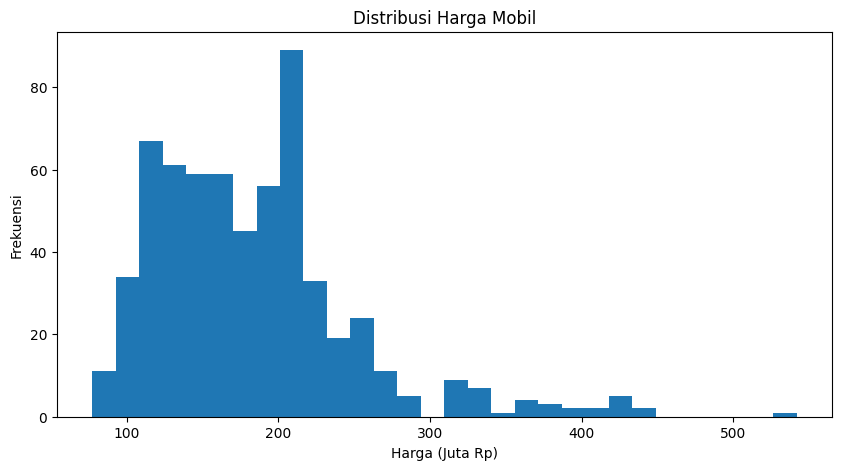

In [7]:
# Cek Distribusi Harga
plt.figure(figsize=(10, 5))
price_million = df['price (Rp)'] / 1_000_000
plt.hist(price_million, bins=30)
plt.title('Distribusi Harga Mobil')
plt.xlabel('Harga (Juta Rp)')
plt.ylabel('Frekuensi')
plt.show()

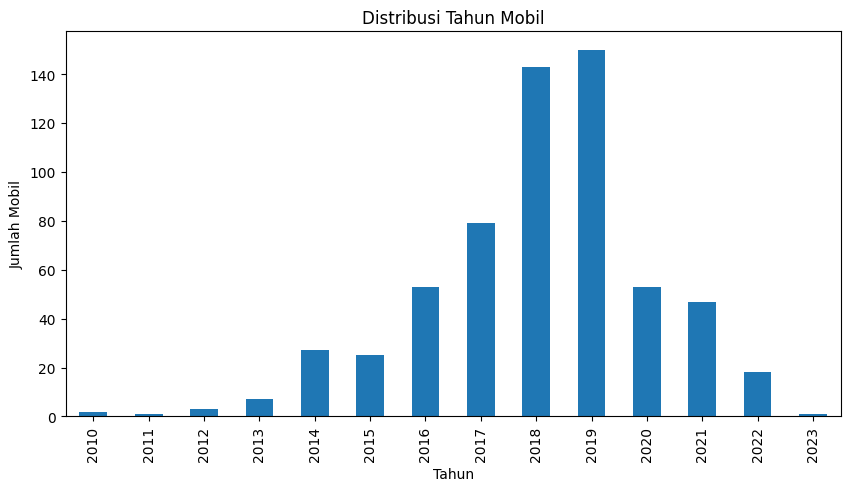

In [8]:
# Cek Distribusi Tahun
plt.figure(figsize=(10, 5))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Tahun Mobil')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Mobil')
plt.show()

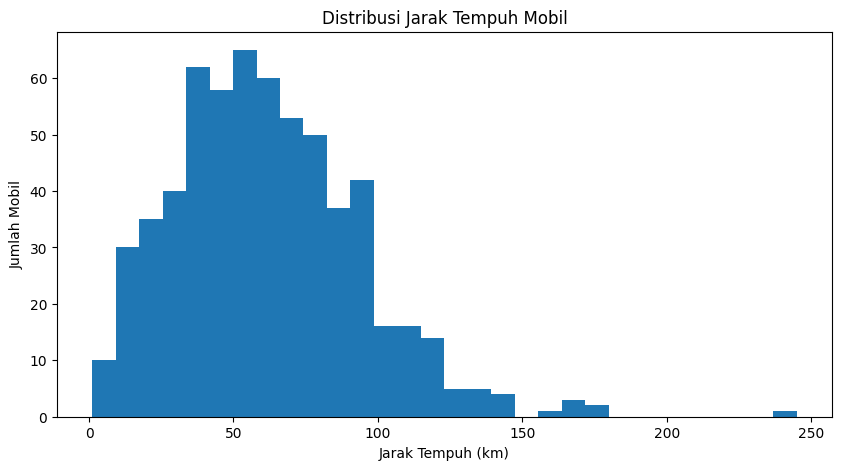

In [9]:
# Cek Distribusi Jarak Tempuh
plt.figure(figsize=(10, 5))
plt.hist(df['mileage (km)'], bins=30)
plt.title('Distribusi Jarak Tempuh Mobil')
plt.xlabel('Jarak Tempuh (km)')
plt.ylabel('Jumlah Mobil')
plt.show()

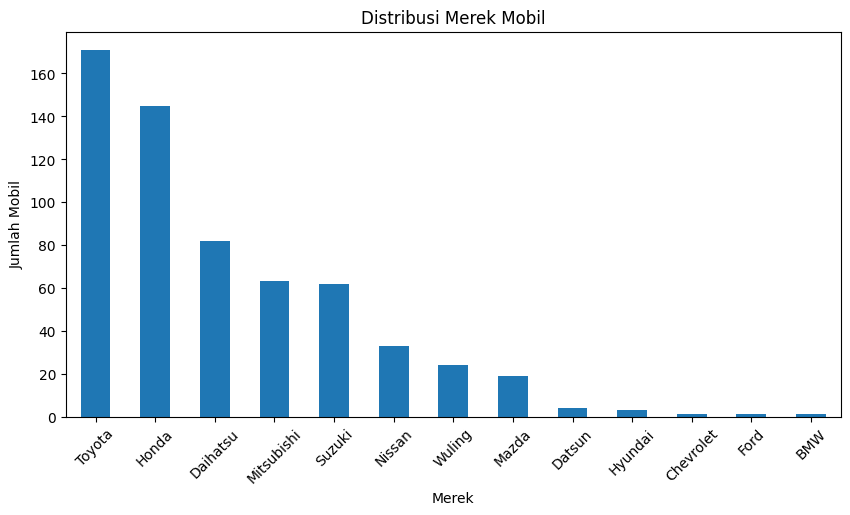

,count
brand,
Toyota,171
Honda,145
Daihatsu,82
Mitsubishi,63
Suzuki,62
Nissan,33
Wuling,24
Mazda,19
Datsun,4


In [10]:
# Cek Distribusi Merek
plt.figure(figsize=(10, 5))
df['brand'].value_counts().plot(kind='bar')
plt.title('Distribusi Merek Mobil')
plt.xlabel('Merek')
plt.ylabel('Jumlah Mobil')
plt.xticks(rotation=45)
plt.show()
df['brand'].value_counts()

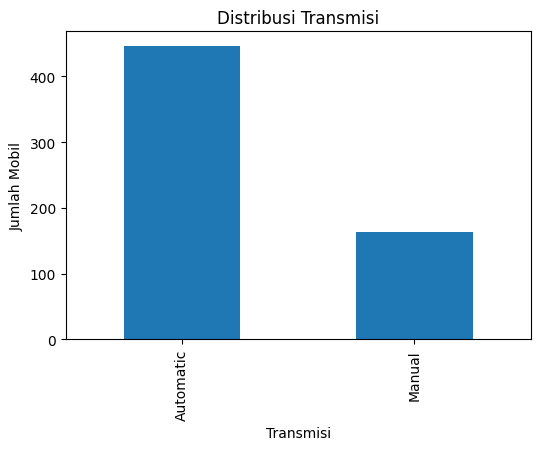

In [11]:
# Cek Distribusi Transmisi
plt.figure(figsize=(6, 4))
df['transmission'].value_counts().plot(kind='bar')
plt.title('Distribusi Transmisi')
plt.xlabel('Transmisi')
plt.ylabel('Jumlah Mobil')
plt.show()

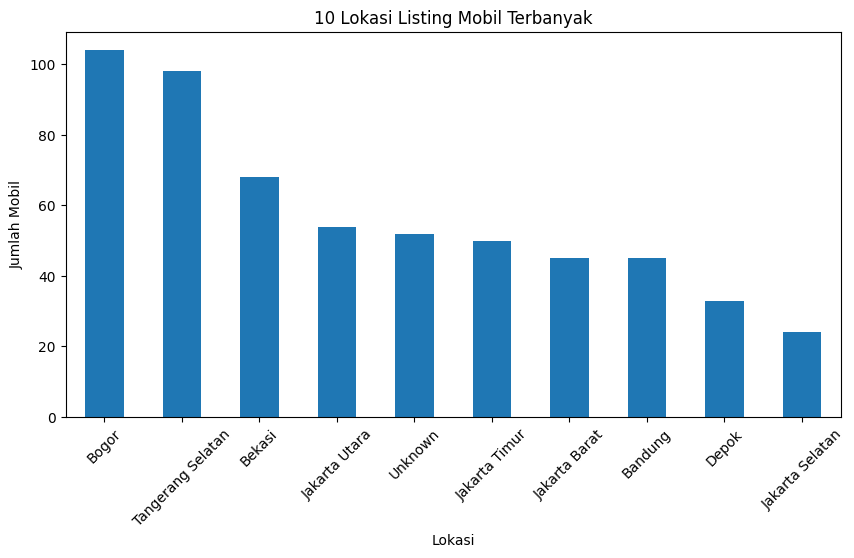

In [12]:
# Cek Distribusi Lokasi
plt.figure(figsize=(10, 5))
df['location'].value_counts().head(10).plot(kind='bar')
plt.title('10 Lokasi Listing Mobil Terbanyak')
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Mobil')
plt.xticks(rotation=45)
plt.show()

In [13]:
# @title Feature Selection
target = 'price (Rp)'

X = df.drop(columns=[target])
y = df[target]

print("Target :", target)
print("Jumlah kandidat fitur :", X.shape[1])
print("\nFitur:")
print(X.columns.tolist())

Target : price (Rp)
Jumlah kandidat fitur : 19

Fitur:
['car name', 'brand', 'year', 'mileage (km)', 'location', 'transmission', 'plate type', 'rear camera', 'sun roof', 'auto retract mirror', 'electric parking brake', 'map navigator', 'vehicle stability control', 'keyless push start', 'sports mode', '360 camera view', 'power sliding door', 'auto cruise control', 'instalment (Rp|Monthly)']


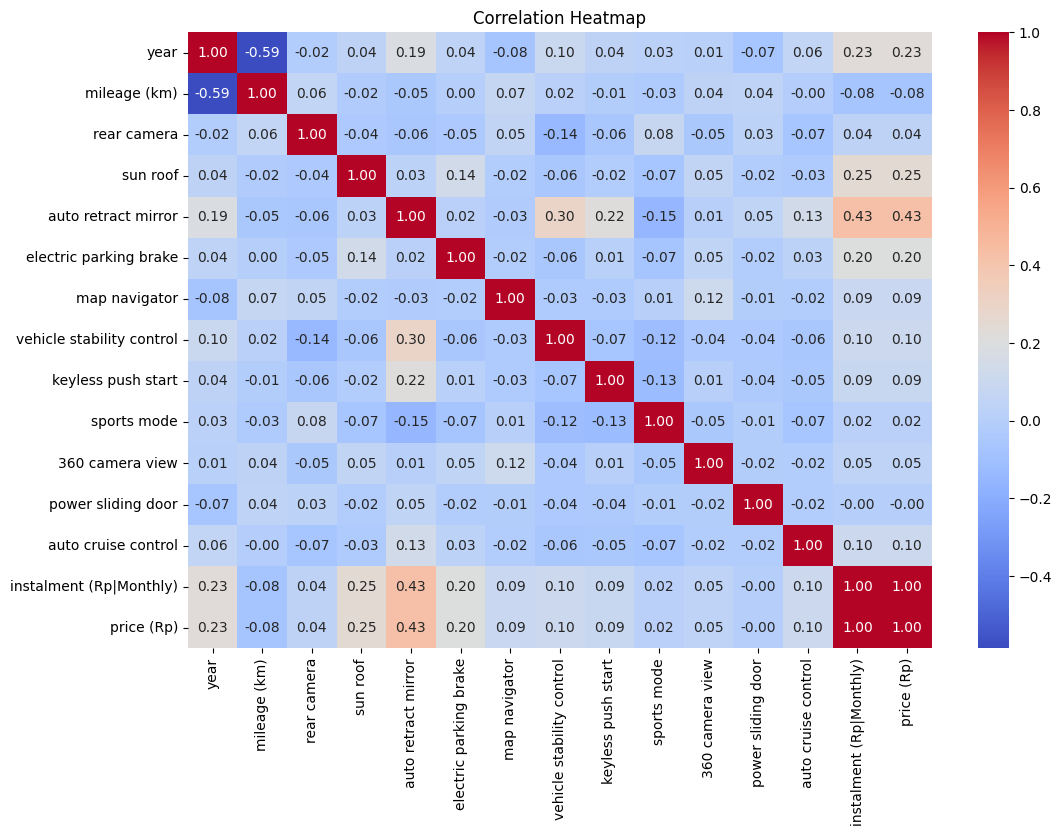

In [14]:
# Correlation Heatmap
numeric_cols = X.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols + [target]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()
# print(X.columns.tolist())

In [15]:
# Mengambil korelasi setiap fitur numerik terhadap target
corr_target = (
    corr[target]
    # Menghapus korelasi target dengan dirinya sendiri
    .drop(target)
    # Mengurutkan korelasi dari nilai terbesar ke terkecil
    .sort_values(ascending=False)
)
# Menampilkan korelasi setiap fitur terhadap target
print(corr_target)

instalment (Rp|Monthly)      0.999998
auto retract mirror          0.426771
sun roof                     0.247568
year                         0.230540
electric parking brake       0.201175
auto cruise control          0.103750
vehicle stability control    0.102740
map navigator                0.089841
keyless push start           0.087837
360 camera view              0.045479
rear camera                  0.038510
sports mode                  0.018852
power sliding door          -0.000367
mileage (km)                -0.077146
Name: price (Rp), dtype: float64


In [16]:
# Mengambil nilai absolut dari korelasi
# sehingga korelasi positif dan negatif dibandingkan berdasarkan kekuatannya
corr_target_abs = corr_target.abs().sort_values(ascending=False)

# Menampilkan korelasi berdasarkan kekuatan terbesar
print(corr_target_abs)

instalment (Rp|Monthly)      0.999998
auto retract mirror          0.426771
sun roof                     0.247568
year                         0.230540
electric parking brake       0.201175
auto cruise control          0.103750
vehicle stability control    0.102740
map navigator                0.089841
keyless push start           0.087837
mileage (km)                 0.077146
360 camera view              0.045479
rear camera                  0.038510
sports mode                  0.018852
power sliding door           0.000367
Name: price (Rp), dtype: float64


Berdasarkan infromasi korelasi fitur dengan target, Fitur instalment (Rp|Monthly) dihapus karena memiliki korelasi 0.999998 dengan target price (Rp). Nilai  ini mengindikasikan bahwa informasi cicilan memiliki hubungan yang sangat langsung dengan harga dan berpotensi menyebabkan data leakage. Oleh karena itu, fitur ini tidak digunakan sebagai input model.

In [17]:
target = 'price (Rp)'
X = df.drop(columns=[
    target,
    'instalment (Rp|Monthly)'
])
y = df[target]
print("Jumlah fitur:", X.shape[1])
print("\nFitur kandidat:")
print(X.columns.tolist())

Jumlah fitur: 18

Fitur kandidat:
['car name', 'brand', 'year', 'mileage (km)', 'location', 'transmission', 'plate type', 'rear camera', 'sun roof', 'auto retract mirror', 'electric parking brake', 'map navigator', 'vehicle stability control', 'keyless push start', 'sports mode', '360 camera view', 'power sliding door', 'auto cruise control']


In [18]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()
print("Categorical:")
print(categorical_cols)
print("\nNumeric:")
print(numeric_cols)

Categorical:
['car name', 'brand', 'location', 'transmission', 'plate type']

Numeric:
['year', 'mileage (km)', 'rear camera', 'sun roof', 'auto retract mirror', 'electric parking brake', 'map navigator', 'vehicle stability control', 'keyless push start', 'sports mode', '360 camera view', 'power sliding door', 'auto cruise control']


**Mutual Information (MI)** digunakan untuk mengukur seberapa banyak informasi yang diberikan oleh suatu fitur terhadap target, yaitu `price (Rp)`. Semakin tinggi nilai MI, semakin besar informasi yang dimiliki fitur tersebut terhadap target. MI diperlukan karena korelasi yang sebelumnya digunakan terutama melihat hubungan linear, sedangkan MI dapat menangkap hubungan yang lebih umum antara fitur dan target. Setelah fitur yang terindikasi data leakage dihapus, MI digunakan untuk membantu menentukan fitur mana yang memiliki informasi terhadap harga dan layak dipertahankan dalam proses pemodelan.


In [19]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression

X_mi = X.copy()
# Encode categorical sementara
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_mi[categorical_cols] = encoder.fit_transform(
    X_mi[categorical_cols]
)
# Hitung Mutual Information
mi = mutual_info_regression(
    X_mi,
    y,
    random_state=42
)
mi_scores = pd.Series(
    mi,
    index=X_mi.columns
).sort_values(ascending=False)
print(mi_scores)

car name                     0.815665
brand                        0.342098
auto retract mirror          0.200220
transmission                 0.165942
year                         0.151201
sports mode                  0.052058
vehicle stability control    0.048368
location                     0.039990
auto cruise control          0.025066
360 camera view              0.023514
keyless push start           0.020033
sun roof                     0.017114
electric parking brake       0.010093
power sliding door           0.003959
plate type                   0.002240
mileage (km)                 0.000000
rear camera                  0.000000
map navigator                0.000000
dtype: float64


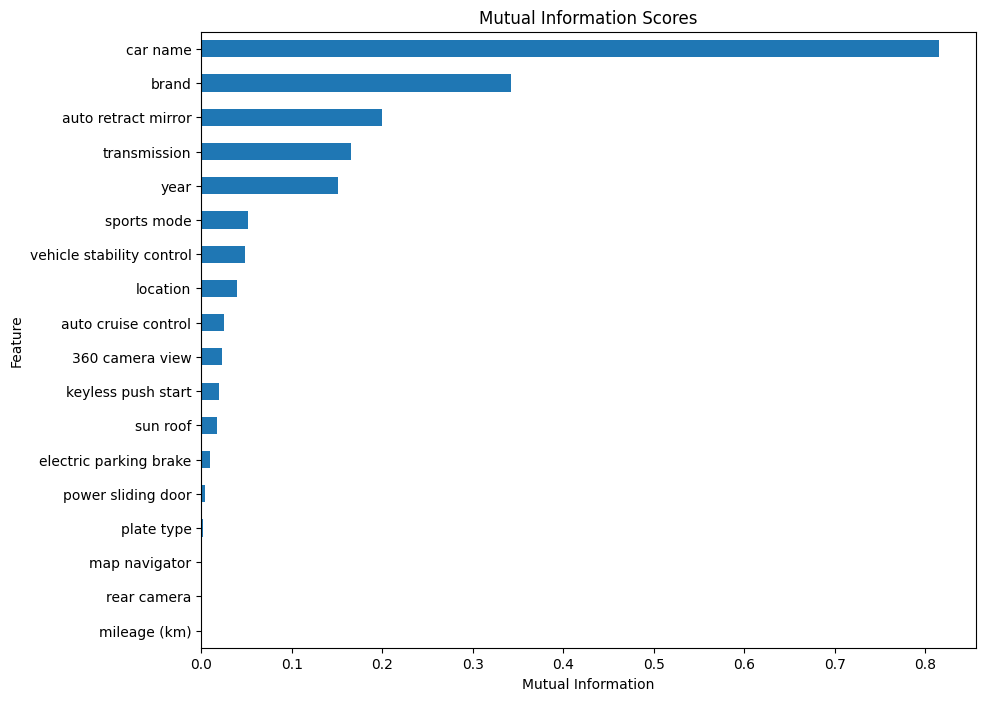

In [20]:
plt.figure(figsize=(10, 8))

mi_scores.sort_values().plot(kind='barh')

plt.title('Mutual Information Scores')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.show()

In [21]:
# Feature Selection berdasarkan Mutual Information
selected_features = [
    'car name',
    'brand',
    'auto retract mirror',
    'transmission',
    'year',
    'vehicle stability control',
    'location',
    'auto cruise control',
    '360 camera view',
    'keyless push start',
    'plate type',
    'mileage (km)'
]

# selected_features = [
#     'car name',
#     'brand',
#     'auto retract mirror',
#     'transmission',
#     'year',
#     'sports mode',
#     'vehicle stability control',
#     'location',
#     'auto cruise control',
#     '360 camera view',
#     'keyless push start',
#     'sun roof',
#     'electric parking brake',
#     'power sliding door',
#     'plate type',
#     'mileage (km)'
# ]

# Buang target dan fitur yang berpotensi leakage
selected_features = [
    col for col in selected_features
    if col not in ['price (Rp)', 'instalment (Rp|Monthly)']
]

X_selected = df[selected_features]
y = df['price (Rp)']

print("Fitur yang dipertahankan:")
print(selected_features)

print("\nJumlah fitur:", len(selected_features))

Fitur yang dipertahankan:
['car name', 'brand', 'auto retract mirror', 'transmission', 'year', 'vehicle stability control', 'location', 'auto cruise control', '360 camera view', 'keyless push start', 'plate type', 'mileage (km)']

Jumlah fitur: 12


In [22]:
# @title Preprocessing
# Cek tipe data fitur terpilih
X_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   car name                   609 non-null    object 
 1   brand                      609 non-null    object 
 2   auto retract mirror        609 non-null    int64  
 3   transmission               609 non-null    object 
 4   year                       609 non-null    int64  
 5   vehicle stability control  609 non-null    int64  
 6   location                   609 non-null    object 
 7   auto cruise control        609 non-null    int64  
 8   360 camera view            609 non-null    int64  
 9   keyless push start         609 non-null    int64  
 10  plate type                 609 non-null    object 
 11  mileage (km)               609 non-null    float64
dtypes: float64(1), int64(6), object(5)
memory usage: 57.2+ KB


In [23]:
# Fitur kategorikal
categorical_cols = X_selected.select_dtypes(include='object').columns.tolist()

# Fitur numerik
numeric_cols = X_selected.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numeric_cols)

Categorical: ['car name', 'brand', 'transmission', 'location', 'plate type']
Numerical: ['auto retract mirror', 'year', 'vehicle stability control', 'auto cruise control', '360 camera view', 'keyless push start', 'mileage (km)']


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Target
y = df['price (Rp)']
# Fitur hasil feature selection
X = df[selected_features]
# 1. Train 70% dan sisa 30%
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
# 2. Sisa 30% dibagi menjadi Validation 15% dan Test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.50,
    random_state=42
)
# 3. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit HANYA menggunakan data training
X_train_processed = preprocessor.fit_transform(X_train)

# Validation dan Test hanya transform
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# 4. Cek hasil split
print("Total data :", len(X))
print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

print("\nShape:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed  :", X_val_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Total data : 609
Train      : 426
Validation : 91
Test       : 92

Shape:
X_train_processed: (426, 184)
X_val_processed  : (91, 184)
X_test_processed : (92, 184)


In [25]:
# @title Modelling

In [26]:
# @title Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model
model_lr = LinearRegression()

# Training
model_lr.fit(X_train_processed, y_train)

# Prediksi validation
y_val_pred_lr = model_lr.predict(X_val_processed)

# Evaluasi
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_lr = r2_score(y_val, y_val_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 15190365.600100737
RMSE: 31773172.512231905
R²  : 0.7468267738287963


In [27]:
# @title Random Forest
from sklearn.ensemble import RandomForestRegressor

# Model
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Training
model_rf.fit(X_train_processed, y_train)

# Prediksi validation
y_val_pred_rf = model_rf.predict(X_val_processed)

# Evaluasi
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_rf = r2_score(y_val, y_val_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 23361428.57142857
RMSE: 43084156.28194978
R²  : 0.5344870152615215


In [28]:
# @title XGBoost

from xgboost import XGBRegressor

# Model
model_xgb = XGBRegressor(
    n_estimators=100,
    random_state=42
)

# Training
model_xgb.fit(X_train_processed, y_train)

# Prediksi validation
y_val_pred_xgb = model_xgb.predict(X_val_processed)

# Evaluasi
mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
r2_xgb = r2_score(y_val, y_val_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 19228262.0
RMSE: 37139338.87323338
R²  : 0.6540886163711548


In [29]:
# @title Model Comparison

# Perbandingan hasil validation
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

# Urutkan berdasarkan RMSE terkecil
comparison = comparison.sort_values('RMSE')

print(comparison)

               Model           MAE          RMSE        R2
0  Linear Regression  1.519037e+07  3.177317e+07  0.746827
2            XGBoost  1.922826e+07  3.713934e+07  0.654089
1      Random Forest  2.336143e+07  4.308416e+07  0.534487


In [30]:
# @title Evaluation test data

# Final Evaluation - Linear Regression pada Test Set

# Prediksi data test
y_test_pred_lr = model_lr.predict(X_test_processed)

# Hitung metrics
mae_test = mean_absolute_error(y_test, y_test_pred_lr)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_test = r2_score(y_test, y_test_pred_lr)

# Tampilkan hasil
print("Final Evaluation - Linear Regression")
print("------------------------------------")
print("MAE :", mae_test)
print("RMSE:", rmse_test)
print("R²  :", r2_test)

Final Evaluation - Linear Regression
------------------------------------
MAE : 16739514.011492165
RMSE: 39447419.323641665
R²  : 0.7714461071512428


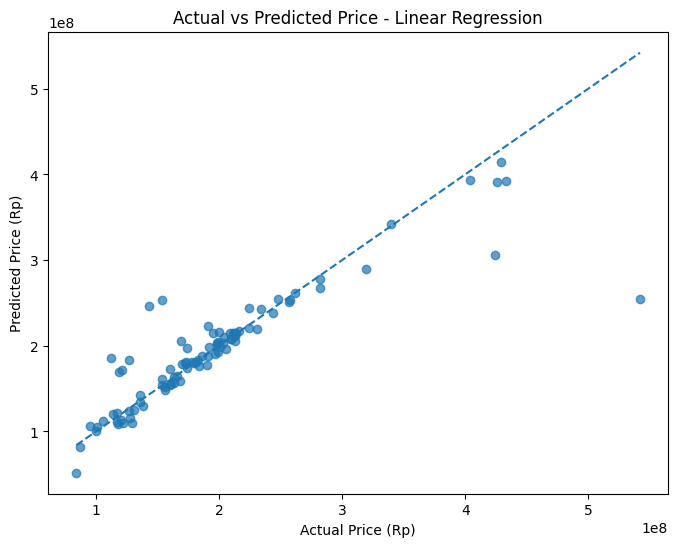

In [31]:
# @title valuation: Actual vs Predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred_lr, alpha=0.7)

# Garis ideal: prediksi = aktual
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Price (Rp)')
plt.ylabel('Predicted Price (Rp)')
plt.title('Actual vs Predicted Price - Linear Regression')
plt.show()

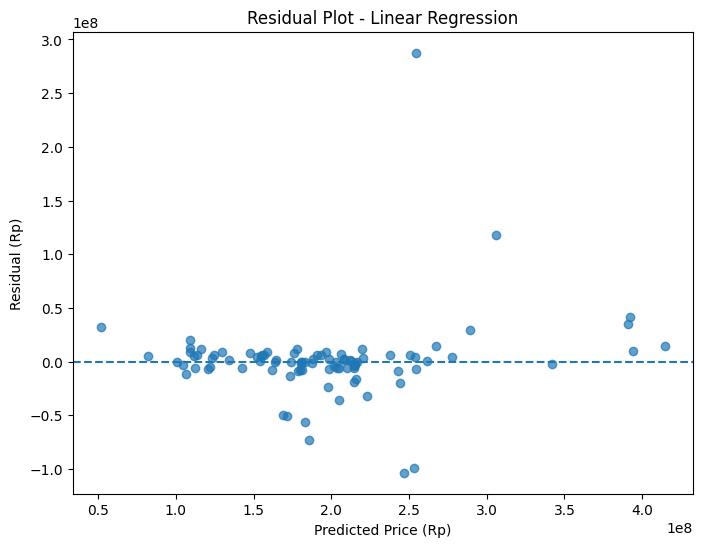

In [32]:
# Residual
residuals = y_test - y_test_pred_lr

plt.figure(figsize=(8, 6))

plt.scatter(y_test_pred_lr, residuals, alpha=0.7)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price (Rp)')
plt.ylabel('Residual (Rp)')
plt.title('Residual Plot - Linear Regression')
plt.show()

In [33]:
# @title Predict New Data
# Data mobil baru untuk prediksi

new_data = pd.DataFrame({
    'car name': ['Toyota Avanza 1.5 G'],
    'brand': ['Toyota'],
    'auto retract mirror': [1],
    'transmission': ['Automatic'],
    'year': [2022],
    'vehicle stability control': [1],
    'location': ['Jakarta'],
    'auto cruise control': [1],
    '360 camera view': [0],
    'keyless push start': [1],
    'plate type': ['B'],
    'mileage (km)': [10.000]
})

new_data

,car name,brand,auto retract mirror,transmission,year,vehicle stability control,location,auto cruise control,360 camera view,keyless push start,plate type,mileage (km)
0,Toyota Avanza 1.5 G,Toyota,1,Automatic,2022,1,Jakarta,1,0,1,B,10.0


In [34]:
# Preprocessing data baru
new_data_processed = preprocessor.transform(new_data)

# Prediksi harga
new_price_pred = model_lr.predict(new_data_processed)

print(f"Prediksi harga mobil: Rp {new_price_pred[0]:,.0f}")

Prediksi harga mobil: Rp 257,684,882


In [35]:
# @title Save Model
import joblib

# Simpan model terbaik
joblib.dump(model_lr, 'linear_regression_model.pkl')

# Simpan preprocessing
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Model dan preprocessor berhasil disimpan.")

# load model
# import joblib

# model_lr = joblib.load('linear_regression_model.pkl')
# preprocessor = joblib.load('preprocessor.pkl')

Model dan preprocessor berhasil disimpan.


In [36]:
car_brand_mapping = (
    df[['car name', 'brand']]
    .drop_duplicates(subset=['car name'])
    .reset_index(drop=True)
)

# Ubah ke format list of dictionaries untuk dropdown
car_dropdown_list = car_brand_mapping.to_dict(orient='records')

for item in car_dropdown_list:
    print(f"{{'label': '{item['car name']} ({item['brand']})', 'value': '{item['car name']}'}}")

{'label': 'AYLA X 1.2 (Daihatsu)', 'value': 'AYLA X 1.2'}
{'label': 'AGYA TRD SPORTIVO 1.0 (Toyota)', 'value': 'AGYA TRD SPORTIVO 1.0'}
{'label': 'X-TRAIL 2.5 (Nissan)', 'value': 'X-TRAIL 2.5'}
{'label': 'YARIS S TRD 1.5 (Toyota)', 'value': 'YARIS S TRD 1.5'}
{'label': 'AGYA G 1.2 (Toyota)', 'value': 'AGYA G 1.2'}
{'label': 'AVANZA G 1.3 (Toyota)', 'value': 'AVANZA G 1.3'}
{'label': 'AVANZA G 1.5 (Toyota)', 'value': 'AVANZA G 1.5'}
{'label': 'OUTLANDER SPORT PX 2.0 (Mitsubishi)', 'value': 'OUTLANDER SPORT PX 2.0'}
{'label': 'BRIO SATYA E 1.2 (Honda)', 'value': 'BRIO SATYA E 1.2'}
{'label': 'HR-V S 1.5 (Honda)', 'value': 'HR-V S 1.5'}
{'label': 'AGYA G TRD 1.2 (Toyota)', 'value': 'AGYA G TRD 1.2'}
{'label': 'AYLA R 1.2 (Daihatsu)', 'value': 'AYLA R 1.2'}
{'label': 'AYLA R DLX 1.2 (Daihatsu)', 'value': 'AYLA R DLX 1.2'}
{'label': 'ALMAZ LT LUX 1.5 (Wuling)', 'value': 'ALMAZ LT LUX 1.5'}
{'label': 'TERIOS TX 1.5 (Daihatsu)', 'value': 'TERIOS TX 1.5'}
{'label': 'MOBILIO E 1.5 (Honda)', 'va

In [37]:
car_dropdown_df = pd.DataFrame(car_dropdown_list)
car_dropdown_df.to_csv('car_dropdown_list.csv', index=False)
print('car_dropdown_list.csv berhasil disimpan.')

car_dropdown_list.csv berhasil disimpan.
